# 路径管理

In [2]:
import sys
import os

# 将 FDCL_v2 项目根目录加入系统路径
project_root = "/root/FDCL_v2"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 验证路径是否已加入
print("当前 sys.path 包含:")
for p in sys.path[:5]:
    print(f"  {p}")

# 现在可以正常导入 SDK 模块
try:
    from SDK.data.label_mappping import remap_labels, apply_label_mapping
    print("导入成功！")
except ImportError as e:
    print(f"导入失败: {e}")
    print("请检查 SDK 目录结构是否完整。")

当前 sys.path 包含:
  /root/FDCL_v2
  /root/miniconda3/lib/python312.zip
  /root/miniconda3/lib/python3.12
  /root/miniconda3/lib/python3.12/lib-dynload
  
导入成功！


# 数据预处理

In [4]:
import os
import yaml
import numpy as np
import pandas as pd
import torch

# =========================================================
# 配置文件路径
# =========================================================
config_path = "/root/FDCL_v2/CPC/config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# 读取 stage2 数据路径（原来为 stage1）
stage2_cfg = cfg["stage2"]
data_paths = stage2_cfg["data_path"]

train_path = data_paths["train_path"]
val_path   = data_paths["val_path"]
test_path  = data_paths["test_path"]

# 检查文件是否存在
for path, name in [(train_path, "train"), (val_path, "val"), (test_path, "test")]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到 stage2 {name} 文件: {path}")

# =========================================================
# 指定要读取的列
# =========================================================
feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
label_col = "class_id"

# =========================================================
# 只读取需要的列
# =========================================================
use_cols = feature_cols + [label_col]

train_df = pd.read_csv(train_path, usecols=use_cols)
val_df   = pd.read_csv(val_path, usecols=use_cols)
test_df  = pd.read_csv(test_path, usecols=use_cols)

print("Stage2 train shape:", train_df.shape)
print("Stage2 val shape  :", val_df.shape)
print("Stage2 test shape :", test_df.shape)

# =========================================================
# 提取特征和标签
# =========================================================
def extract_features_labels(df, feature_cols, label_col):
    X = df[feature_cols].values.astype(np.float32)
    y = df[label_col].values.astype(np.int64).reshape(-1)
    return X, y

X_train, y_train = extract_features_labels(train_df, feature_cols, label_col)
X_val, y_val     = extract_features_labels(val_df, feature_cols, label_col)
X_test, y_test   = extract_features_labels(test_df, feature_cols, label_col)

print("\nRaw feature shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\nLabel statistics:")
print("Train unique classes:", np.unique(y_train))
print("Val   unique classes:", np.unique(y_val))
print("Test  unique classes:", np.unique(y_test))

# =========================================================
# 转换为 PyTorch Tensor
# =========================================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

print("\nFinal tensor shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

Stage2 train shape: (15000, 5)
Stage2 val shape  : (5000, 5)
Stage2 test shape : (5000, 5)

Raw feature shapes:
X_train: (15000, 4) y_train: (15000,)
X_val  : (5000, 4) y_val  : (5000,)
X_test : (5000, 4) y_test : (5000,)

Label statistics:
Train unique classes: [1 4 5 6 7]
Val   unique classes: [1 4 5 6 7]
Test  unique classes: [1 4 5 6 7]

Final tensor shapes:
X_train: torch.Size([15000, 4]) y_train: torch.Size([15000])
X_val  : torch.Size([5000, 4]) y_val  : torch.Size([5000])
X_test : torch.Size([5000, 4]) y_test : torch.Size([5000])


## 原始数据tsne图

已抽样 3000 个样本用于绘图
正在执行 t-SNE，请耐心等待...


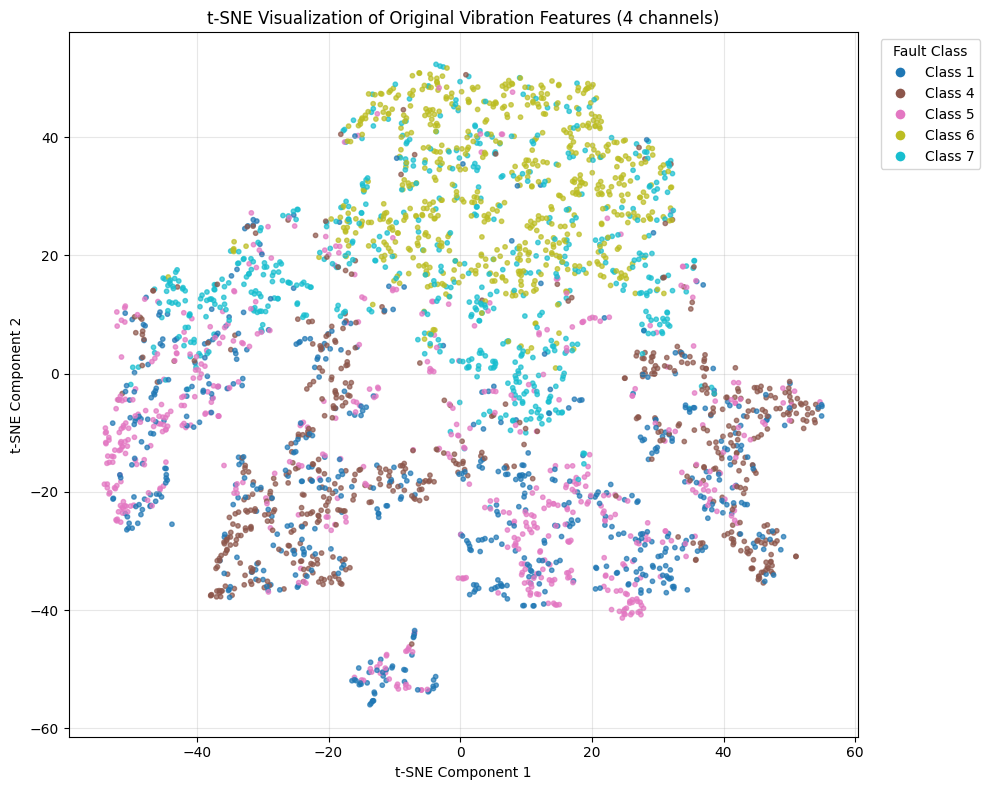

In [5]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# =========================================================
# 数据准备（确保 X_train, y_train 已存在）
# =========================================================
if hasattr(X_train, 'numpy'):
    X_np = X_train.numpy()
    y_np = y_train.numpy()
else:
    X_np = np.array(X_train)
    y_np = np.array(y_train)

# 抽样避免过慢
max_samples = 3000
if X_np.shape[0] > max_samples:
    indices = np.random.choice(X_np.shape[0], max_samples, replace=False)
    X_plot = X_np[indices]
    y_plot = y_np[indices]
    print(f"已抽样 {max_samples} 个样本用于绘图")
else:
    X_plot = X_np
    y_plot = y_np

# =========================================================
# t-SNE 降维（兼容多版本参数）
# =========================================================
print("正在执行 t-SNE，请耐心等待...")

# 尝试使用新版参数 'max_iter'，若失败则回退至旧版 'n_iter'
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

X_tsne = tsne.fit_transform(X_plot)

# =========================================================
# 绘图
# =========================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_plot, cmap='tab10', alpha=0.7, s=10)

# 图例
classes = np.unique(y_plot)
legend_handles = []
for cls in classes:
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=scatter.cmap(scatter.norm(cls)),
                                     markersize=8, label=f'Class {cls}'))
plt.legend(handles=legend_handles, title='Fault Class', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.title('t-SNE Visualization of Original Vibration Features (4 channels)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 滑窗处理，转换成符合CPC输入条件的数据

In [6]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# =========================================================
# 可调参数
# =========================================================
WINDOW_SIZE = 256      # 每个样本的时间步长
STRIDE = 128            # 滑动步长（重叠采样可增加数据量）
# RANDOM_SEED = 42

# =========================================================
# 假设你已经执行过前面的数据读取代码，变量如下：
# train_df, val_df, test_df: pandas DataFrame，包含原始时序数据
# feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
# label_col = "class_id"
# =========================================================

# -------------------- 辅助函数：创建序列 --------------------
def create_sequences_from_df(df, feature_cols, label_col, window_size, stride):
    """
    将按时间排序的 DataFrame 转换为滑动窗口序列。
    返回: X_seq (num_windows, channels, window_size), y_seq (num_windows,)
    """
    # 提取数值并保持原始顺序（假定 df 已经按时间排列）
    data = df[feature_cols].values.astype(np.float32)   # (T, C)
    labels = df[label_col].values.astype(np.int64)      # (T,)

    X_list, y_list = [], []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]                # (window_size, C)
        X_list.append(window.T)                 # 转置为 (C, window_size)
        y_list.append(labels[end - 1])          # 使用窗口末尾的标签

    X_seq = np.stack(X_list, axis=0)            # (N, C, window_size)
    y_seq = np.array(y_list)
    return X_seq, y_seq

# -------------------- 标准化 --------------------
# 使用训练集计算均值和标准差
scaler = StandardScaler()
train_raw = train_df[feature_cols].values.astype(np.float32)
scaler.fit(train_raw)

def scale_df(df):
    data = df[feature_cols].values.astype(np.float32)
    scaled = scaler.transform(data)
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaled
    return df_scaled

train_scaled = scale_df(train_df)
val_scaled   = scale_df(val_df)
test_scaled  = scale_df(test_df)

# -------------------- 生成序列 --------------------
print("正在生成 CPC 序列...")
X_train_cpc, y_train_cpc = create_sequences_from_df(
    train_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)
X_val_cpc, y_val_cpc = create_sequences_from_df(
    val_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)
X_test_cpc, y_test_cpc = create_sequences_from_df(
    test_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)

# -------------------- 转为 Tensor --------------------
X_train_cpc = torch.tensor(X_train_cpc, dtype=torch.float32)
y_train_cpc = torch.tensor(y_train_cpc, dtype=torch.long)
X_val_cpc   = torch.tensor(X_val_cpc, dtype=torch.float32)
y_val_cpc   = torch.tensor(y_val_cpc, dtype=torch.long)
X_test_cpc  = torch.tensor(X_test_cpc, dtype=torch.float32)
y_test_cpc  = torch.tensor(y_test_cpc, dtype=torch.long)

# -------------------- 输出信息 --------------------
print("\n✅ CPC 格式数据生成完成！")
print("=" * 50)
print(f"窗口长度     : {WINDOW_SIZE}")
print(f"滑动步长     : {STRIDE}")
print(f"通道数       : {len(feature_cols)} ({', '.join(feature_cols)})")
print("-" * 50)
print(f"训练集序列数 : {X_train_cpc.shape[0]}")
print(f"验证集序列数 : {X_val_cpc.shape[0]}")
print(f"测试集序列数 : {X_test_cpc.shape[0]}")
print("-" * 50)
print("张量形状 (batch, channels, seq_len):")
print(f"X_train_cpc : {tuple(X_train_cpc.shape)}")
print(f"X_val_cpc   : {tuple(X_val_cpc.shape)}")
print(f"X_test_cpc  : {tuple(X_test_cpc.shape)}")
print("=" * 50)

# 可选：查看一个样本的统计信息
print(f"\n示例 - 第一个训练序列的均值: {X_train_cpc[0].mean():.4f}, 标准差: {X_train_cpc[0].std():.4f}")
print(f"对应标签: {y_train_cpc[0].item()}")

正在生成 CPC 序列...

✅ CPC 格式数据生成完成！
窗口长度     : 256
滑动步长     : 128
通道数       : 4 (vibration_ch1, vibration_ch2, vibration_ch3, vibration_ch4)
--------------------------------------------------
训练集序列数 : 116
验证集序列数 : 38
测试集序列数 : 38
--------------------------------------------------
张量形状 (batch, channels, seq_len):
X_train_cpc : (116, 4, 256)
X_val_cpc   : (38, 4, 256)
X_test_cpc  : (38, 4, 256)

示例 - 第一个训练序列的均值: 0.0087, 标准差: 1.3074
对应标签: 1


##  旧CPC直接在新数据集上进行测试

CPC 模型加载成功。
使用已存在的 Stage2 序列数据，形状: torch.Size([116, 4, 256])
正在计算 Stage2 训练集每个样本的损失...
Stage2 训练集类别跳变次数: 4


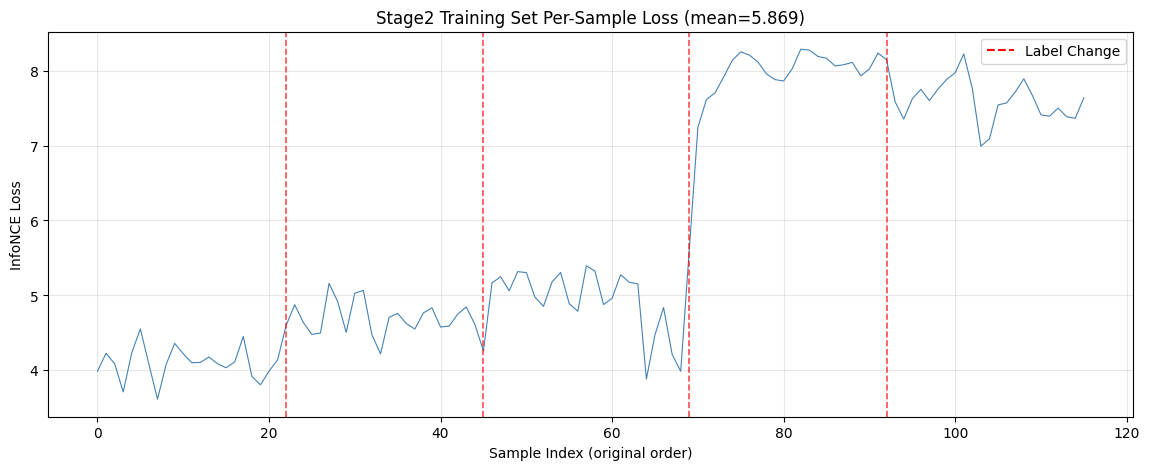

图片已保存至: /root/FDCL_v2/CPC/stage2/result/stage2_train_loss_with_changes.png

===== Stage2 训练集损失统计 =====
样本数: 116
均值: 5.8687
标准差: 1.6262
最小值: 3.6146
最大值: 8.2856


In [10]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# =========================================================
# 配置路径与参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CPC 模型路径（来自 Stage1 训练结果）
cpc_model_path = "/root/FDCL_v2/CPC/stage1/result/best_cpc_model.pth"

# Stage2 结果保存目录
result_dir = "/root/FDCL_v2/CPC/stage2/result"
os.makedirs(result_dir, exist_ok=True)

# CPC 序列参数（与训练时完全一致）
WINDOW_SIZE = 256
STRIDE = 128
batch_size = 64   # 损失计算时的批次大小

# =========================================================
# 1. 加载 CPC 模型
# =========================================================
# 请确保 CPCModel 类已在当前环境定义（若未定义，请先运行 CPC 类定义 Cell）
model = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(cpc_model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("CPC 模型加载成功。")

# =========================================================
# 2. 准备 Stage2 训练数据（若未生成序列，则自动处理）
# =========================================================
# 检查是否已有 Stage2 序列数据变量
if 'X_train_stage2_cpc' not in dir():
    print("未找到 Stage2 序列数据，正在从原始 DataFrame 生成...")
    # 请确保 train_df（Stage2训练集原始DataFrame）已存在（运行Stage2数据读取Cell后可得）
    if 'train_df' not in dir():
        raise NameError("变量 train_df 未定义，请先运行 Stage2 数据读取 Cell。")
    
    feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
    label_col = "class_id"
    
    # 标准化
    scaler = StandardScaler()
    train_raw = train_df[feature_cols].values.astype(np.float32)
    scaler.fit(train_raw)
    
    def scale_df(df):
        data = df[feature_cols].values.astype(np.float32)
        scaled = scaler.transform(data)
        df_scaled = df.copy()
        df_scaled[feature_cols] = scaled
        return df_scaled
    
    train_scaled = scale_df(train_df)
    
    # 滑动窗口生成序列
    def create_sequences_from_df(df, feature_cols, label_col, window_size, stride):
        data = df[feature_cols].values.astype(np.float32)
        labels = df[label_col].values.astype(np.int64)
        X_list, y_list = [], []
        for start in range(0, len(data) - window_size + 1, stride):
            end = start + window_size
            window = data[start:end]
            X_list.append(window.T)
            y_list.append(labels[end - 1])
        return np.stack(X_list, axis=0), np.array(y_list)
    
    X_train_stage2_cpc, y_train_stage2_raw = create_sequences_from_df(
        train_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
    )
    X_train_stage2_cpc = torch.tensor(X_train_stage2_cpc, dtype=torch.float32)
    y_train_stage2_raw = torch.tensor(y_train_stage2_raw, dtype=torch.long)
    print(f"Stage2 训练序列生成完成，形状: {X_train_stage2_cpc.shape}")
else:
    print(f"使用已存在的 Stage2 序列数据，形状: {X_train_stage2_cpc.shape}")
    # 确保标签也存在
    if 'y_train_stage2_raw' not in dir():
        raise NameError("变量 y_train_stage2_raw 未定义，请确保已生成序列标签。")

# =========================================================
# 3. 定义按样本计算损失的函数
# =========================================================
@torch.no_grad()
def compute_per_sample_loss(model, x):
    """返回形状为 (batch,) 的每个样本平均 InfoNCE 损失"""
    batch_size, _, seq_len = x.shape
    pred_steps = model.pred_steps

    z = model.encoder(x).permute(0, 2, 1)          # (B, T, z_dim)
    context = model.ar(z)                          # (B, T, context_dim)

    per_sample_loss = torch.zeros(batch_size, device=x.device)
    total_counts = torch.zeros(batch_size, device=x.device)

    for k in range(1, pred_steps + 1):
        t_max = seq_len - k
        if t_max <= 0:
            continue
        pred = model.predictor(context, k)[:, :t_max, :]
        z_all_flat = z.reshape(-1, z.shape[-1])

        for b in range(batch_size):
            pred_b = pred[b]
            logits = torch.matmul(pred_b, z_all_flat.T)
            labels = (b * seq_len) + torch.arange(k, k + t_max, device=x.device)
            loss_per_t = F.cross_entropy(logits, labels, reduction='none')
            per_sample_loss[b] += loss_per_t.sum()
            total_counts[b] += t_max

    per_sample_loss = per_sample_loss / total_counts.clamp(min=1)
    return per_sample_loss

# =========================================================
# 4. 分批计算 Stage2 训练集损失
# =========================================================
print("正在计算 Stage2 训练集每个样本的损失...")
losses_stage2 = []
total_samples = X_train_stage2_cpc.shape[0]
for i in range(0, total_samples, batch_size):
    batch_x = X_train_stage2_cpc[i:i+batch_size].to(device)
    loss_batch = compute_per_sample_loss(model, batch_x).cpu().numpy()
    losses_stage2.extend(loss_batch.tolist())
losses_stage2 = np.array(losses_stage2)

# 获取标签（numpy 格式）
y_np = y_train_stage2_raw.numpy() if torch.is_tensor(y_train_stage2_raw) else np.array(y_train_stage2_raw)

# =========================================================
# 5. 找出类别跳变位置
# =========================================================
def find_label_change_indices(labels):
    """返回所有发生标签跳变的样本索引（跳变后的第一个样本位置）"""
    change_indices = np.where(np.diff(labels) != 0)[0] + 1
    return change_indices

stage2_changes = find_label_change_indices(y_np)
print(f"Stage2 训练集类别跳变次数: {len(stage2_changes)}")

# =========================================================
# 6. 绘制折线图（与之前风格一致）
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(range(len(losses_stage2)), losses_stage2, linewidth=0.8, color='steelblue')
for idx in stage2_changes:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.xlabel('Sample Index (original order)')
plt.ylabel('InfoNCE Loss')
plt.title(f'Stage2 Training Set Per-Sample Loss (mean={losses_stage2.mean():.3f})')
plt.grid(alpha=0.3)
plt.plot([], [], color='red', linestyle='--', label='Label Change')
plt.legend()

# 保存图片到新目录
save_path = os.path.join(result_dir, "stage2_train_loss_with_changes.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"图片已保存至: {save_path}")

# =========================================================
# 7. 统计摘要
# =========================================================
print("\n===== Stage2 训练集损失统计 =====")
print(f"样本数: {len(losses_stage2)}")
print(f"均值: {losses_stage2.mean():.4f}")
print(f"标准差: {losses_stage2.std():.4f}")
print(f"最小值: {losses_stage2.min():.4f}")
print(f"最大值: {losses_stage2.max():.4f}")

## 标签重映射

In [5]:
import os
import numpy as np

# =========================================================
# 映射表路径
# =========================================================
mapping_file = "/root/FDCL_v2/CPC/stage1/result/label_mapping.csv"

# =========================================================
# 1. 检查映射表是否存在且非空
# =========================================================
if not os.path.exists(mapping_file) or os.path.getsize(mapping_file) == 0:
    print("映射表不存在或为空，将使用训练集标签初始化映射...")
    # 第一次建立映射（基于训练集标签）
    y_train_mapped, label_map, map_df = remap_labels(
        y=y_train_cpc,
        old_map_csv=None,
        save_map_csv=mapping_file,
        verbose=True
    )
    print(f"已生成映射表并保存至: {mapping_file}")
else:
    print("映射表已存在且非空，直接读取并应用映射。")

# =========================================================
# 2. 应用映射到训练/验证/测试集
# =========================================================
y_train_mapped, y_train_origin = apply_label_mapping(
    mapping_csv=mapping_file,
    y=y_train_cpc,
    old_label_col="old_label",
    new_label_col="new_label",
    verbose=True
)

y_val_mapped, y_val_origin = apply_label_mapping(
    mapping_csv=mapping_file,
    y=y_val_cpc,
    old_label_col="old_label",
    new_label_col="new_label",
    verbose=False
)

y_test_mapped, y_test_origin = apply_label_mapping(
    mapping_csv=mapping_file,
    y=y_test_cpc,
    old_label_col="old_label",
    new_label_col="new_label",
    verbose=False
)

# =========================================================
# 3. 输出结果摘要
# =========================================================
print("\n映射后标签统计：")
print(f"训练集唯一标签: {np.unique(y_train_mapped)}")
print(f"验证集唯一标签: {np.unique(y_val_mapped)}")
print(f"测试集唯一标签: {np.unique(y_test_mapped)}")
print("\n训练集新标签示例（前10个）:", y_train_mapped[:10])

映射表已存在且非空，直接读取并应用映射。

Apply existing label mapping:
{0: 0, 1: 1, 3: 2, 4: 3, 5: 4}

Mapped label stats:
origin unique: [0 1 3 4 5]
mapped unique: [0 1 2 3 4]
num_classes  : 5

映射后标签统计：
训练集唯一标签: [0 1 2 3 4]
验证集唯一标签: [0 1 2 3 4]
测试集唯一标签: [0 1 2 3 4]

训练集新标签示例（前10个）: [0 0 0 0 0 0 0 0 0 0]


## CPC动态特征计算

### CPC模型定义

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CPCEncoder(nn.Module):
    """编码器：将原始输入映射到潜在表示 z_t"""
    def __init__(self, input_dim, hidden_dim, z_dim):
        super().__init__()
        # 示例：一个简单的卷积编码器（适用于时序数据）
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, z_dim, kernel_size=3, stride=1, padding=1)
        )
    
    def forward(self, x):
        # x 形状: (batch, input_dim, seq_len)
        return self.conv(x)  # 输出: (batch, z_dim, seq_len)

class CPCAutoregressive(nn.Module):
    """自回归模型：根据过去的 z 生成上下文向量 c_t"""
    def __init__(self, z_dim, hidden_dim, context_dim):
        super().__init__()
        self.gru = nn.GRU(z_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, context_dim)
    
    def forward(self, z):
        # z 形状: (batch, seq_len, z_dim)
        gru_out, _ = self.gru(z)  # gru_out: (batch, seq_len, hidden_dim)
        context = self.fc(gru_out)  # (batch, seq_len, context_dim)
        return context

class CPCPredictor(nn.Module):
    """预测头：对于每一个未来步 k，将上下文向量映射到预测表示"""
    def __init__(self, context_dim, z_dim, num_steps=5):
        super().__init__()
        self.num_steps = num_steps
        # 为每一个预测步 k 学习一个线性变换矩阵 W_k
        self.Wk = nn.ModuleList([
            nn.Linear(context_dim, z_dim, bias=False) for _ in range(num_steps)
        ])
    
    def forward(self, context, k):
        # context: (batch, seq_len, context_dim)
        # 返回对第 k 步未来的预测表示
        return self.Wk[k-1](context)  # (batch, seq_len, z_dim)

class CPCModel(nn.Module):
    """CPC 整体模型"""
    def __init__(self, input_dim, encoder_hidden_dim=256, z_dim=128,
                 ar_hidden_dim=256, context_dim=128, pred_steps=5):
        super().__init__()
        self.pred_steps = pred_steps
        self.z_dim = z_dim
        
        self.encoder = CPCEncoder(input_dim, encoder_hidden_dim, z_dim)
        self.ar = CPCAutoregressive(z_dim, ar_hidden_dim, context_dim)
        self.predictor = CPCPredictor(context_dim, z_dim, pred_steps)
    
    def forward(self, x):
        # x: (batch, input_dim, seq_len)
        batch_size, _, seq_len = x.shape
        
        # 1. 编码得到 z
        z = self.encoder(x)                     # (batch, z_dim, seq_len)
        z = z.permute(0, 2, 1)                  # (batch, seq_len, z_dim)
        
        # 2. 生成上下文向量 c_t
        context = self.ar(z)                    # (batch, seq_len, context_dim)
        
        # 3. 收集正负样本并计算 InfoNCE 损失
        loss, accuracy = self._compute_infonce(z, context)
        return loss, accuracy
    
    def _compute_infonce(self, z, context):
        """
        计算 InfoNCE 损失。
        对每个时间步 t 和每个预测步 k，真实未来 z_{t+k} 为正样本，
        同一批次内其他时间步（或随机采样）的 z 为负样本。
        """
        batch_size, seq_len, z_dim = z.shape
        total_loss = 0.0
        correct = 0
        total = 0
        
        # 循环每个预测步 k
        for k in range(1, self.pred_steps + 1):
            # 预测对第 k 步未来的表示: W_k c_t
            pred = self.predictor(context, k)           # (batch, seq_len, z_dim)
            
            # 正样本：真实的未来 z_{t+k}
            # 为了对齐时间维度，截取有效部分
            t_max = seq_len - k
            if t_max <= 0:
                continue
            
            # 取对应时间的预测和真实未来
            pred_valid = pred[:, :t_max, :]              # (batch, t_max, z_dim)
            z_future = z[:, k:, :]                       # (batch, t_max, z_dim)
            
            # 计算相似度分数（点积）
            # pred_valid: (batch, t_max, z_dim) -> 展平为 (batch * t_max, z_dim)
            # z_all: (batch * seq_len, z_dim) 作为所有候选负样本
            z_all_flat = z.reshape(-1, z_dim)            # (batch * seq_len, z_dim)
            
            # 预测与所有候选的相似度矩阵
            pred_flat = pred_valid.reshape(-1, z_dim)    # (batch * t_max, z_dim)
            logits = torch.matmul(pred_flat, z_all_flat.T)  # (batch * t_max, batch * seq_len)
            
            # 构造标签：正样本的位置索引
            # 对于每个 (batch_i, t)，正样本是同一序列同一批次的未来时间步
            indices = torch.arange(batch_size * t_max, device=z.device)
            labels = (indices // t_max) * seq_len + (indices % t_max) + k
            labels = labels.long()
            
            # 交叉熵损失
            loss_k = F.cross_entropy(logits, labels)
            total_loss += loss_k
            
            # 计算准确率
            pred_idx = logits.argmax(dim=1)
            correct += (pred_idx == labels).sum().item()
            total += labels.size(0)
        
        avg_loss = total_loss / self.pred_steps
        accuracy = correct / total if total > 0 else 0.0
        return avg_loss, accuracy

    def get_representations(self, x):
        """提取特征表示（上下文向量或潜在向量），供下游任务使用"""
        z = self.encoder(x).permute(0, 2, 1)  # (batch, seq_len, z_dim)
        context = self.ar(z)                  # (batch, seq_len, context_dim)
        return context   # 也可选择返回 z


## CPC模型训练

使用设备: cuda
训练批次数: 1, 验证批次数: 1

开始训练 CPC 模型...


Epoch 1/50 [Train]: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s, loss=10.2967, acc=0.0000]


Epoch   1 | Train Loss: 10.2967 | Train Acc: 0.0000 | Val Loss: 9.0961 | Val Acc: 0.0002 | LR: 1.00e-03
  --> 保存最佳模型 (Val Loss: 9.0961)


Epoch 2/50 [Train]: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s, loss=10.2117, acc=0.0001]


Epoch   2 | Train Loss: 10.2117 | Train Acc: 0.0001 | Val Loss: 8.9304 | Val Acc: 0.0002 | LR: 1.00e-03
  --> 保存最佳模型 (Val Loss: 8.9304)


...

Epoch  48 | Train Loss: 5.3791 | Train Acc: 0.0679 | Val Loss: 4.2655 | Val Acc: 0.1392 | LR: 1.00e-03
  --> 保存最佳模型 (Val Loss: 4.2655)


Epoch 49/50 [Train]: 100%|██████████| 1/1 [00:00<00:00,  2.64it/s, loss=5.2816, acc=0.0787]


Epoch  49 | Train Loss: 5.2816 | Train Acc: 0.0787 | Val Loss: 4.2098 | Val Acc: 0.1444 | LR: 1.00e-03
  --> 保存最佳模型 (Val Loss: 4.2098)


Epoch 50/50 [Train]: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s, loss=5.2204, acc=0.0807]


Epoch  50 | Train Loss: 5.2204 | Train Acc: 0.0807 | Val Loss: 4.1577 | Val Acc: 0.1422 | LR: 1.00e-03
  --> 保存最佳模型 (Val Loss: 4.1577)


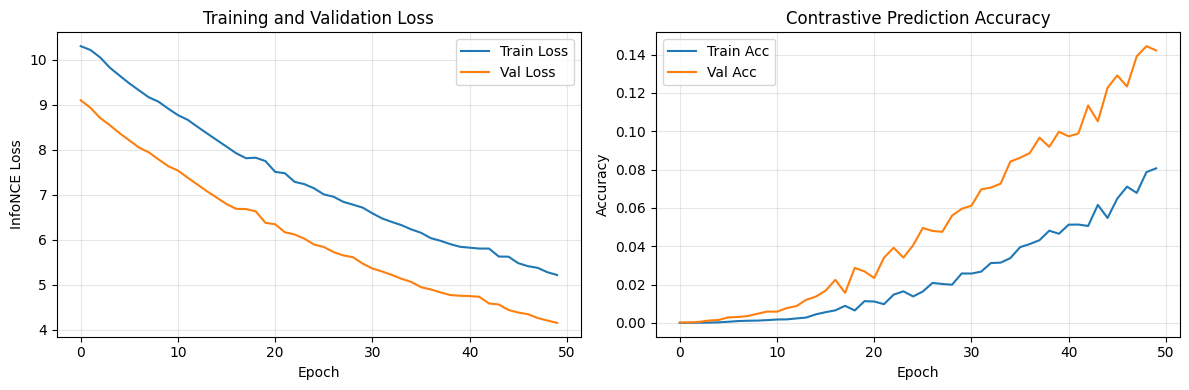


训练完成！最佳验证损失: 4.1577 (Epoch 50)


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# =========================================================
# 超参数配置
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 数据参数（需与预处理时一致）
input_dim = 4           # 振动通道数
seq_len = 256           # WINDOW_SIZE
batch_size = 128        # 可根据显存调整

# 模型参数
encoder_hidden_dim = 256
z_dim = 128
ar_hidden_dim = 256
context_dim = 128
pred_steps = 5

# 训练参数
epochs = 50
learning_rate = 1e-3
weight_decay = 1e-5
patience = 10           # 早停耐心值

# 保存路径
save_dir = "./cpc_checkpoints"
os.makedirs(save_dir, exist_ok=True)

# =========================================================
# 构建 DataLoader（假设 X_train_cpc 等已存在）
# =========================================================
train_dataset = TensorDataset(X_train_cpc, y_train_cpc)
val_dataset   = TensorDataset(X_val_cpc, y_val_cpc)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"训练批次数: {len(train_loader)}, 验证批次数: {len(val_loader)}")

# =========================================================
# 初始化模型、优化器、调度器
# =========================================================
model = CPCModel(
    input_dim=input_dim,
    encoder_hidden_dim=encoder_hidden_dim,
    z_dim=z_dim,
    ar_hidden_dim=ar_hidden_dim,
    context_dim=context_dim,
    pred_steps=pred_steps
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# =========================================================
# 训练循环
# =========================================================
best_val_loss = float('inf')
best_epoch = 0
no_improve_epochs = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\n开始训练 CPC 模型...")
for epoch in range(1, epochs + 1):
    # -------------------- 训练阶段 --------------------
    model.train()
    total_train_loss = 0.0
    total_train_acc = 0.0
    train_batches = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]")
    for batch_x, batch_y in pbar:
        batch_x = batch_x.to(device)   # (B, C, T)
        
        optimizer.zero_grad()
        loss, acc = model(batch_x)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_acc += acc
        train_batches += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc:.4f}'})
    
    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    
    # -------------------- 验证阶段 --------------------
    model.eval()
    total_val_loss = 0.0
    total_val_acc = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            loss, acc = model(batch_x)
            
            total_val_loss += loss.item()
            total_val_acc += acc
            val_batches += 1
    
    avg_val_loss = total_val_loss / val_batches
    avg_val_acc = total_val_acc / val_batches
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)
    
    # 调整学习率
    scheduler.step(avg_val_loss)
    
    # 打印 epoch 结果
    print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # -------------------- 模型保存与早停 --------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        no_improve_epochs = 0
        
        # 保存最佳模型
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'val_acc': avg_val_acc,
        }, os.path.join(save_dir, 'best_cpc_model.pth'))
        print(f"  --> 保存最佳模型 (Val Loss: {best_val_loss:.4f})")
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print(f"\n早停触发！验证损失连续 {patience} 个 epoch 未改善。")
            break

# =========================================================
# 绘制训练曲线
# =========================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Contrastive Prediction Accuracy')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'cpc_training_curves.png'), dpi=150)
plt.show()

print(f"\n训练完成！最佳验证损失: {best_val_loss:.4f} (Epoch {best_epoch})")

## 训练后的嵌入表达可视化

使用设备: cuda
模型加载成功。
使用数据集: train, 原始样本数: 116
提取的嵌入形状: (116, 128)
正在执行 t-SNE 降维...


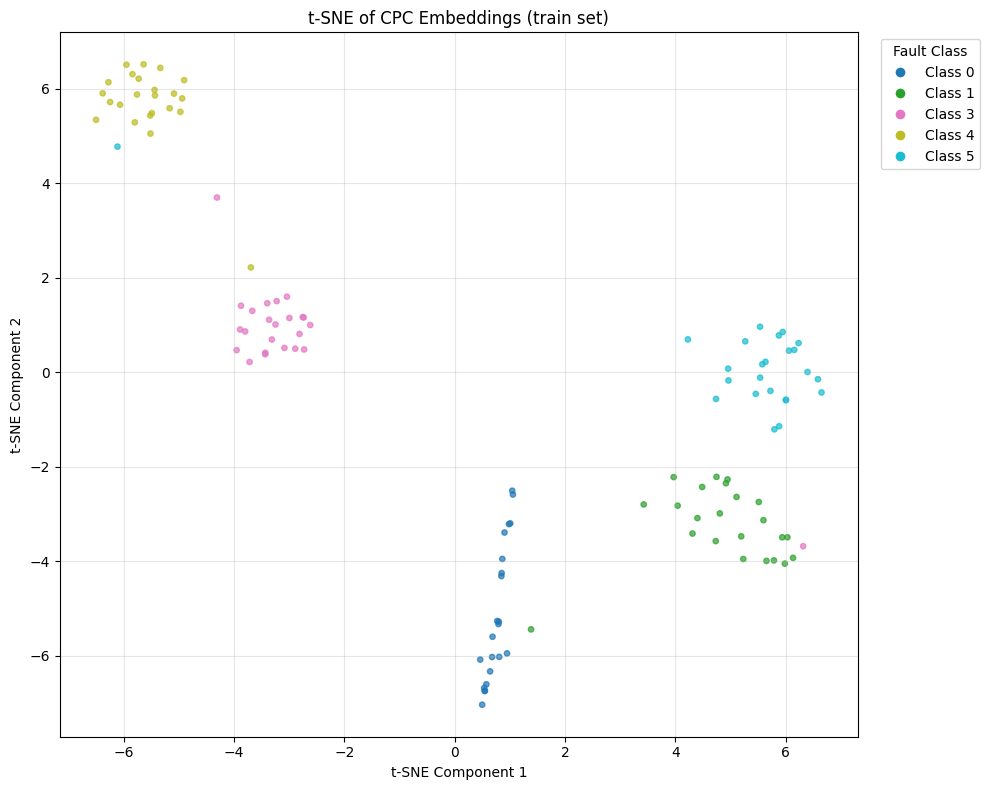

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

model_path = "./cpc_checkpoints/best_cpc_model.pth"
data_choice = 'train'          # 可选 'train', 'val', 'test'
max_samples = 3000
perplexity = 30
random_state = 42

# =========================================================
# 1. 加载模型（使用训练时的原始尺寸）
# =========================================================
model = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,    # 训练时使用的原始值
    z_dim=128,                 # 训练时使用的原始值
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("模型加载成功。")

# =========================================================
# 2. 准备数据
# =========================================================
if data_choice == 'train':
    X_data, y_data = X_train_cpc, y_train_cpc
elif data_choice == 'val':
    X_data, y_data = X_val_cpc, y_val_cpc
else:
    X_data, y_data = X_test_cpc, y_test_cpc

print(f"使用数据集: {data_choice}, 原始样本数: {X_data.shape[0]}")

if X_data.shape[0] > max_samples:
    indices = np.random.choice(X_data.shape[0], max_samples, replace=False)
    X_plot, y_plot = X_data[indices], y_data[indices]
    print(f"已随机抽样 {max_samples} 个样本")
else:
    X_plot, y_plot = X_data, y_data

# =========================================================
# 3. 提取 CPC 嵌入（分批处理，避免显存溢出）
# =========================================================
batch_size = 32   # 因为模型较大，batch_size 适当调小
features_list = []

with torch.no_grad():
    for i in range(0, len(X_plot), batch_size):
        batch_x = X_plot[i:i+batch_size].to(device)
        context = model.get_representations(batch_x)          # (B, seq_len, context_dim)
        global_feat = context.mean(dim=1).cpu().numpy()      # 时间维平均
        features_list.append(global_feat)

features = np.concatenate(features_list, axis=0)
labels = y_plot.numpy() if torch.is_tensor(y_plot) else np.array(y_plot)
print(f"提取的嵌入形状: {features.shape}")

# =========================================================
# 4. t-SNE 降维
# =========================================================
print("正在执行 t-SNE 降维...")
try:
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, n_iter=1000)

features_2d = tsne.fit_transform(features)

# =========================================================
# 5. 绘图
# =========================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=15)

classes = np.unique(labels)
legend_handles = []
for cls in classes:
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=scatter.cmap(scatter.norm(cls)),
                                     markersize=8, label=f'Class {cls}'))
plt.legend(handles=legend_handles, title='Fault Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title(f't-SNE of CPC Embeddings ({data_choice} set)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 每个样本的loss显示

模型加载成功。
训练集样本数: 116
测试集样本数: 38

正在计算训练集每个样本的损失...
  训练集 处理进度: 32 / 116

正在计算测试集每个样本的损失...
  测试集 处理进度: 32 / 38

训练集类别跳变次数: 4
测试集类别跳变次数: 4


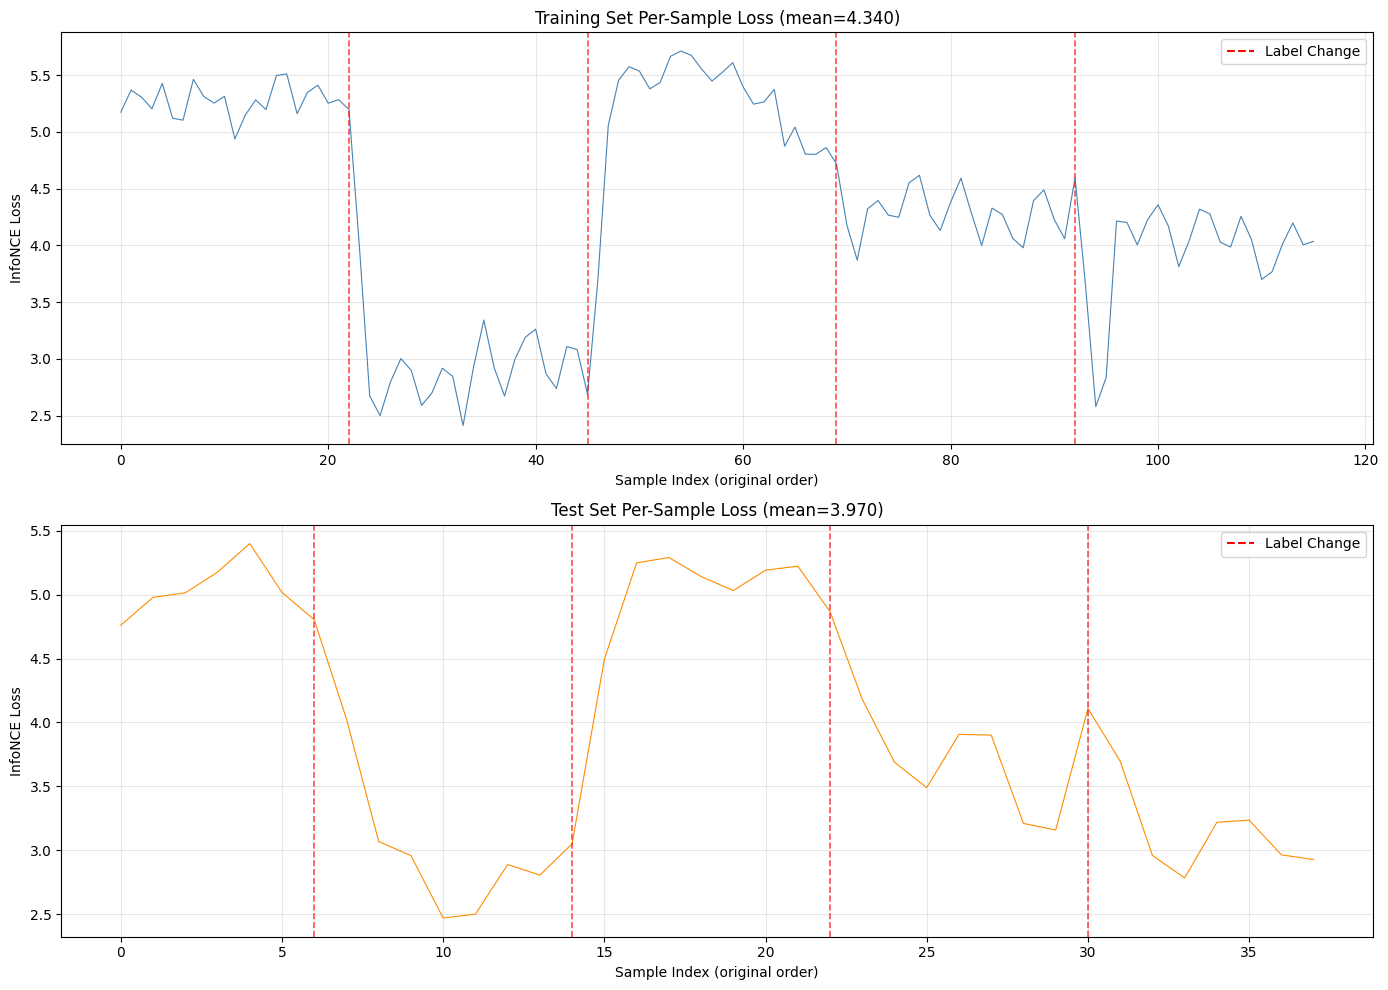


===== 损失统计 =====
训练集 - 均值: 4.3397, 标准差: 0.9387, 最小: 2.4126, 最大: 5.7132
测试集 - 均值: 3.9697, 标准差: 0.9593, 最小: 2.4708, 最大: 5.3995


In [9]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "./cpc_checkpoints/best_cpc_model.pth"
batch_size = 32
max_samples = None          # 若不为 None，则限制样本数以加快测试

# =========================================================
# 1. 加载模型
# =========================================================
model = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("模型加载成功。")

# =========================================================
# 2. 损失计算函数（同前）
# =========================================================
@torch.no_grad()
def compute_per_sample_loss(model, x):
    batch_size, _, seq_len = x.shape
    pred_steps = model.pred_steps

    z = model.encoder(x).permute(0, 2, 1)
    context = model.ar(z)

    per_sample_loss = torch.zeros(batch_size, device=x.device)
    total_counts = torch.zeros(batch_size, device=x.device)

    for k in range(1, pred_steps + 1):
        t_max = seq_len - k
        if t_max <= 0:
            continue

        pred = model.predictor(context, k)[:, :t_max, :]
        z_future = z[:, k:, :]

        z_all_flat = z.reshape(-1, z.shape[-1])

        for b in range(batch_size):
            pred_b = pred[b]
            logits = torch.matmul(pred_b, z_all_flat.T)
            labels = (b * seq_len) + torch.arange(k, k + t_max, device=x.device)
            loss_per_t = F.cross_entropy(logits, labels, reduction='none')
            per_sample_loss[b] += loss_per_t.sum()
            total_counts[b] += t_max

    per_sample_loss = per_sample_loss / total_counts.clamp(min=1)
    return per_sample_loss

def compute_losses_for_dataset(X_data, desc="数据"):
    losses_list = []
    total = X_data.shape[0]
    for i in range(0, total, batch_size):
        batch_x = X_data[i:i+batch_size].to(device)
        loss_batch = compute_per_sample_loss(model, batch_x).cpu().numpy()
        losses_list.append(loss_batch)
        if (i // batch_size) % 20 == 0:
            print(f"  {desc} 处理进度: {i + len(batch_x)} / {total}")
    return np.concatenate(losses_list, axis=0)

# =========================================================
# 3. 准备数据与标签
# =========================================================
if max_samples is not None:
    X_train_plot = X_train_cpc[:max_samples]
    y_train_plot = y_train_cpc[:max_samples]
    X_test_plot = X_test_cpc[:max_samples]
    y_test_plot = y_test_cpc[:max_samples]
    print(f"已限制每个数据集最多使用 {max_samples} 个样本")
else:
    X_train_plot = X_train_cpc
    y_train_plot = y_train_cpc
    X_test_plot = X_test_cpc
    y_test_plot = y_test_cpc

print(f"训练集样本数: {X_train_plot.shape[0]}")
print(f"测试集样本数: {X_test_plot.shape[0]}")

# 计算损失
print("\n正在计算训练集每个样本的损失...")
train_losses = compute_losses_for_dataset(X_train_plot, desc="训练集")

print("\n正在计算测试集每个样本的损失...")
test_losses = compute_losses_for_dataset(X_test_plot, desc="测试集")

# 获取标签的 numpy 数组（方便比较相邻值）
y_train_np = y_train_plot.numpy() if torch.is_tensor(y_train_plot) else np.array(y_train_plot)
y_test_np = y_test_plot.numpy() if torch.is_tensor(y_test_plot) else np.array(y_test_plot)

# =========================================================
# 4. 找出类别跳变的位置（相邻样本标签不同）
# =========================================================
def find_label_change_indices(labels):
    """返回所有发生标签跳变的样本索引（跳变后的第一个样本位置）"""
    change_indices = np.where(np.diff(labels) != 0)[0] + 1
    return change_indices

train_changes = find_label_change_indices(y_train_np)
test_changes = find_label_change_indices(y_test_np)

print(f"\n训练集类别跳变次数: {len(train_changes)}")
print(f"测试集类别跳变次数: {len(test_changes)}")

# =========================================================
# 5. 绘制分开的折线图，并标注类别跳变时刻
# =========================================================
plt.figure(figsize=(14, 10))

# 子图1：训练集
plt.subplot(2, 1, 1)
plt.plot(range(len(train_losses)), train_losses, linewidth=0.8, color='steelblue')
# 标注类别跳变位置（红色虚线）
for idx in train_changes:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.xlabel('Sample Index (original order)')
plt.ylabel('InfoNCE Loss')
plt.title(f'Training Set Per-Sample Loss (mean={train_losses.mean():.3f})')
plt.grid(alpha=0.3)
# 添加图例说明
plt.plot([], [], color='red', linestyle='--', label='Label Change')
plt.legend()

# 子图2：测试集
plt.subplot(2, 1, 2)
plt.plot(range(len(test_losses)), test_losses, linewidth=0.8, color='darkorange')
for idx in test_changes:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.xlabel('Sample Index (original order)')
plt.ylabel('InfoNCE Loss')
plt.title(f'Test Set Per-Sample Loss (mean={test_losses.mean():.3f})')
plt.grid(alpha=0.3)
plt.plot([], [], color='red', linestyle='--', label='Label Change')
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6. 统计摘要
# =========================================================
print("\n===== 损失统计 =====")
print(f"训练集 - 均值: {train_losses.mean():.4f}, 标准差: {train_losses.std():.4f}, "
      f"最小: {train_losses.min():.4f}, 最大: {train_losses.max():.4f}")
print(f"测试集 - 均值: {test_losses.mean():.4f}, 标准差: {test_losses.std():.4f}, "
      f"最小: {test_losses.min():.4f}, 最大: {test_losses.max():.4f}")

# 分类头

## 分类头定义

In [10]:
import torch
import torch.nn as nn

class MLPClassifier(nn.Module):
    """
    多层感知机分类器
    Args:
        input_dim: 输入特征维度（例如 CPC context_dim 或全局池化后的维度）
        hidden_dims: 列表，每个元素为对应隐藏层的神经元数量，例如 [256, 128]
        num_classes: 分类类别数
        dropout: Dropout 概率，默认 0.3
        use_batch_norm: 是否在隐藏层后使用批归一化，默认 True
        activation: 激活函数，默认 nn.ReLU()
    """
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3, 
                 use_batch_norm=True, activation=nn.ReLU()):
        super().__init__()
        
        layers = []
        dims = [input_dim] + hidden_dims
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        
        # 输出层（无激活、无批归一化）
        layers.append(nn.Linear(dims[-1], num_classes))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        x: (batch_size, input_dim)
        返回: logits (batch_size, num_classes)
        """
        return self.net(x)

## MLP初始化

In [11]:
# =========================================================
# 2. 初始化 MLP（根据你的 CPC 配置和数据集）
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 参数配置（需与你训练 CPC 时的输出维度及数据集类别数一致）
CPC_CONTEXT_DIM = 128        # CPC 上下文向量的维度（你训练时使用的 context_dim）
HIDDEN_DIMS = [256, 128]     # MLP 隐藏层结构
NUM_CLASSES = 5              # 你的故障类别总数（请根据实际数据修改）

mlp_classifier = MLPClassifier(
    input_dim=CPC_CONTEXT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout=0.3,
    use_batch_norm=True
).to(device)

print(f"MLP 分类器已初始化，结构如下：\n{mlp_classifier}")
print(f"设备: {device}")

# =========================================================
# 3. 可选：查看参数总量
# =========================================================
total_params = sum(p.numel() for p in mlp_classifier.parameters())
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}，可训练参数量: {trainable_params:,}")

MLP 分类器已初始化，结构如下：
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)
设备: cuda
总参数量: 67,333，可训练参数量: 67,333


## 训练

使用设备: cuda
训练集标签唯一值: tensor([0, 1, 2, 3, 4])
类别数: 5
CPC 模型加载成功。
正在提取训练集 CPC 特征...
正在提取测试集 CPC 特征...
训练特征形状: torch.Size([116, 128])
测试特征形状: torch.Size([38, 128])

MLP 结构:
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)

开始训练 MLP 分类器...


Epoch 1/100: 100%|██████████| 1/1 [00:00<00:00, 97.69it/s, loss=1.8745]


Epoch  1 | Train Loss: 1.8745 | Test Acc: 0.2105 | LR: 1.00e-03


Epoch 2/100: 100%|██████████| 1/1 [00:00<00:00, 137.71it/s, loss=1.3911]


Epoch  2 | Train Loss: 1.3911 | Test Acc: 0.1579 | LR: 1.00e-03


...

Epoch 98 | Train Loss: 0.0294 | Test Acc: 0.8947 | LR: 6.25e-05


Epoch 99/100: 100%|██████████| 1/1 [00:00<00:00, 182.15it/s, loss=0.0230]


Epoch 99 | Train Loss: 0.0230 | Test Acc: 0.8947 | LR: 6.25e-05


Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 198.32it/s, loss=0.0245]


Epoch 100 | Train Loss: 0.0245 | Test Acc: 0.8947 | LR: 6.25e-05


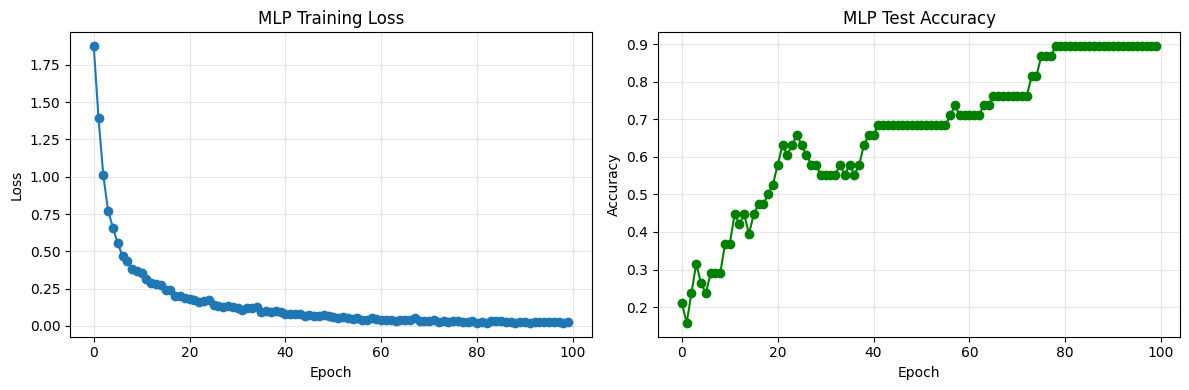


最佳测试准确率: 0.8947


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

cpc_model_path = "./cpc_checkpoints/best_cpc_model.pth"

batch_size_extract = 64
mlp_hidden_dims = [256, 128]
mlp_dropout = 0.3
mlp_epochs = 100
mlp_batch_size = 128
mlp_lr = 1e-3
mlp_weight_decay = 1e-5

# =========================================================
# 1. 标签检查与类别数确定（使用映射后的标签）
# =========================================================
# 确保使用映射后的标签，且是 PyTorch Tensor
y_train = torch.as_tensor(y_train_mapped, dtype=torch.long)
y_test  = torch.as_tensor(y_test_mapped, dtype=torch.long)

# 计算类别数
num_classes = len(torch.unique(y_train))
print(f"训练集标签唯一值: {torch.unique(y_train)}")
print(f"类别数: {num_classes}")

# 验证标签范围是否合法
assert y_train.min() >= 0, "标签包含负数！"
assert y_train.max() < num_classes, "标签最大值超出类别数范围！"

# =========================================================
# 2. 定义 MLP 分类器
# =========================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3, use_batch_norm=True):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# =========================================================
# 3. 加载 CPC 模型并提取特征
# =========================================================
# 请确保 CPCModel 类已定义在当前环境中
model_cpc = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(cpc_model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model_cpc.load_state_dict(checkpoint['model_state_dict'])
else:
    model_cpc.load_state_dict(checkpoint)
model_cpc.eval()
print("CPC 模型加载成功。")

@torch.no_grad()
def extract_cpc_features(model, X_data, batch_size):
    features_list = []
    total = X_data.shape[0]
    for i in range(0, total, batch_size):
        batch_x = X_data[i:i+batch_size].to(device)
        context = model.get_representations(batch_x)      # (B, seq_len, context_dim)
        pooled = context.mean(dim=1).cpu()                # (B, context_dim)
        features_list.append(pooled)
    return torch.cat(features_list, dim=0)

print("正在提取训练集 CPC 特征...")
X_train_feat = extract_cpc_features(model_cpc, X_train_cpc, batch_size_extract)
print("正在提取测试集 CPC 特征...")
X_test_feat = extract_cpc_features(model_cpc, X_test_cpc, batch_size_extract)

print(f"训练特征形状: {X_train_feat.shape}")
print(f"测试特征形状: {X_test_feat.shape}")

# =========================================================
# 4. 构建 DataLoader（使用映射后标签）
# =========================================================
train_dataset = TensorDataset(X_train_feat, y_train)
test_dataset  = TensorDataset(X_test_feat, y_test)

train_loader = DataLoader(train_dataset, batch_size=mlp_batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=mlp_batch_size, shuffle=False)

# =========================================================
# 5. 初始化 MLP 并训练
# =========================================================
mlp = MLPClassifier(
    input_dim=X_train_feat.shape[1],
    hidden_dims=mlp_hidden_dims,
    num_classes=num_classes,
    dropout=mlp_dropout,
    use_batch_norm=True
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=mlp_lr, weight_decay=mlp_weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nMLP 结构:\n{mlp}")

train_losses = []
test_accs = []
best_acc = 0.0

print("\n开始训练 MLP 分类器...")
for epoch in range(1, mlp_epochs + 1):
    mlp.train()
    total_loss = 0.0
    train_batches = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{mlp_epochs}")
    for batch_x, batch_y in pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = mlp(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        train_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = total_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 测试评估
    mlp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = mlp(batch_x)
            preds = logits.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    test_acc = correct / total
    test_accs.append(test_acc)
    
    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Test Acc: {test_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(mlp.state_dict(), "./cpc_checkpoints/best_mlp_classifier.pth")

# =========================================================
# 6. 绘制训练曲线
# =========================================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_accs, marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Test Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n最佳测试准确率: {best_acc:.4f}")